In [139]:
import pandas as pd
import matplotlib.pyplot as pt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

In [140]:
df =pd.read_csv('unclean_data.csv')

In [141]:
df.head()

,Farm_ID,Crop_Type,Farm_Location,Nitrogen_Percent,Phosphorus_ppm,Potassium_ppm,Soil_pH,Rainfall_mm,Yield_kg_per_ha,Planting_Date,Harvest_Date
0,GH-00360,Cassava,Brong Ahafo,0.88,25.9,210.3,4.58,1377.7,9439.3,2022-05-01,2023-02-28
1,GH-00844,Groundnut,Brong Ahafo,1.61,23.8,278.0,5.87,1129.7,1469.7,2022-08-08,2022-12-15
2,GH-00845,Yam,Brong Ahafo,2.36,18.9,243.8,5.66,1135.1,14754.1,2022-10-02,2023-04-04
3,GH-00329,Soybean,Upper West,1.51,19.1,187.4,6.66,1024.3,2103.8,2023-08-04,2023-11-22
4,GH-01507,Soybean,Northern,2.67,13.5,146.5,5.72,1016.9,1281.4,2022-04-21,2022-07-29


In [142]:
df.sample(5)

,Farm_ID,Crop_Type,Farm_Location,Nitrogen_Percent,Phosphorus_ppm,Potassium_ppm,Soil_pH,Rainfall_mm,Yield_kg_per_ha,Planting_Date,Harvest_Date
448,GH-01450,Cocoa,Ashanti,2.36,43.4,251.4,4.85,1798.0,1147.2,2023-03-15,2024-01-02
1397,GH-00977,Soybean,Central,2.19,35.6,226.7,5.12,1183.2,1514.1,2022-04-08,2022-07-13
596,GH-01072,Rice,Western,2.89,NaN,NaN,6.24,2070.7,2216.8,2023-12-12,2024-04-07
1386,GH-01844,Cassava,Eastern,2.56,36.9,68.0,6.97,1382.6,17645.1,2023-03-25,2024-02-04
606,GH-00956,Cassava,Eastern,1.94,22.4,175.1,5.51,1671.0,16449.9,2023-07-13,2024-12-05


In [143]:
df.shape

(2060, 11)

In [144]:
df.describe()

,Nitrogen_Percent,Phosphorus_ppm,Potassium_ppm,Soil_pH,Rainfall_mm,Yield_kg_per_ha
count,1958.000000,1957.000000,1957.000000,2060.000000,1958.000000,1957.000000
mean,2.006798,27.502708,176.350077,5.999544,1275.702503,5921.080991
std,0.864735,12.983853,72.309140,0.855135,289.256133,5454.090886
min,0.500000,5.000000,50.400000,4.500000,791.700000,400.500000
25%,1.260000,16.300000,116.100000,5.290000,1059.350000,1718.700000
50%,2.040000,27.700000,177.200000,6.000000,1189.800000,3259.000000
75%,2.760000,38.300000,239.700000,6.730000,1437.975000,9939.100000
max,3.500000,50.000000,299.900000,7.500000,2093.300000,19997.800000


In [145]:
df.isnull().sum()

Farm_ID               0
Crop_Type           101
Farm_Location         0
Nitrogen_Percent    102
Phosphorus_ppm      103
Potassium_ppm       103
Soil_pH               0
Rainfall_mm         102
Yield_kg_per_ha     103
Planting_Date         0
Harvest_Date          0
dtype: int64

In [146]:
df.duplicated().sum()

np.int64(48)

In [147]:
df =df.drop_duplicates()

In [148]:
df.duplicated().sum()

np.int64(0)

In [149]:
df

,Farm_ID,Crop_Type,Farm_Location,Nitrogen_Percent,Phosphorus_ppm,Potassium_ppm,Soil_pH,Rainfall_mm,Yield_kg_per_ha,Planting_Date,Harvest_Date
0,GH-00360,Cassava,Brong Ahafo,0.88,25.9,210.3,4.58,1377.7,9439.3,2022-05-01,2023-02-28
1,GH-00844,Groundnut,Brong Ahafo,1.61,23.8,278.0,5.87,1129.7,1469.7,2022-08-08,2022-12-15
2,GH-00845,Yam,Brong Ahafo,2.36,18.9,243.8,5.66,1135.1,14754.1,2022-10-02,2023-04-04
3,GH-00329,Soybean,Upper West,1.51,19.1,187.4,6.66,1024.3,2103.8,2023-08-04,2023-11-22
4,GH-01507,Soybean,Northern,2.67,13.5,146.5,5.72,1016.9,1281.4,2022-04-21,2022-07-29
...,...,...,...,...,...,...,...,...,...,...,...
2055,GH-00632,Cocoa,Northern,2.40,NaN,192.4,5.85,1001.6,600.4,2022-05-19,2023-01-24
2056,GH-00578,Plantain,Brong Ahafo,2.05,5.4,139.1,6.37,1268.5,12902.8,2023-11-09,2024-03-25
2057,GH-01401,Cassava,Ashanti,1.95,39.4,114.9,6.62,1989.8,14638.2,2023-04-28,2024-05-02
2058,GH-00614,Rice,Upper East,1.39,38.3,285.9,5.22,1099.6,2256.5,2023-11-04,2024-03-13


In [150]:
df.dtypes

Farm_ID              object
Crop_Type            object
Farm_Location        object
Nitrogen_Percent    float64
Phosphorus_ppm      float64
Potassium_ppm       float64
Soil_pH             float64
Rainfall_mm         float64
Yield_kg_per_ha     float64
Planting_Date        object
Harvest_Date         object
dtype: object

In [151]:
df['Planting_Date'] = pd.to_datetime(df['Planting_Date'])
df['Harvest_Date'] = pd.to_datetime(df['Harvest_Date'])

In [152]:
df.dtypes

Farm_ID                     object
Crop_Type                   object
Farm_Location               object
Nitrogen_Percent           float64
Phosphorus_ppm             float64
Potassium_ppm              float64
Soil_pH                    float64
Rainfall_mm                float64
Yield_kg_per_ha            float64
Planting_Date       datetime64[ns]
Harvest_Date        datetime64[ns]
dtype: object

In [153]:
df

,Farm_ID,Crop_Type,Farm_Location,Nitrogen_Percent,Phosphorus_ppm,Potassium_ppm,Soil_pH,Rainfall_mm,Yield_kg_per_ha,Planting_Date,Harvest_Date
0,GH-00360,Cassava,Brong Ahafo,0.88,25.9,210.3,4.58,1377.7,9439.3,2022-05-01,2023-02-28
1,GH-00844,Groundnut,Brong Ahafo,1.61,23.8,278.0,5.87,1129.7,1469.7,2022-08-08,2022-12-15
2,GH-00845,Yam,Brong Ahafo,2.36,18.9,243.8,5.66,1135.1,14754.1,2022-10-02,2023-04-04
3,GH-00329,Soybean,Upper West,1.51,19.1,187.4,6.66,1024.3,2103.8,2023-08-04,2023-11-22
4,GH-01507,Soybean,Northern,2.67,13.5,146.5,5.72,1016.9,1281.4,2022-04-21,2022-07-29
...,...,...,...,...,...,...,...,...,...,...,...
2055,GH-00632,Cocoa,Northern,2.40,NaN,192.4,5.85,1001.6,600.4,2022-05-19,2023-01-24
2056,GH-00578,Plantain,Brong Ahafo,2.05,5.4,139.1,6.37,1268.5,12902.8,2023-11-09,2024-03-25
2057,GH-01401,Cassava,Ashanti,1.95,39.4,114.9,6.62,1989.8,14638.2,2023-04-28,2024-05-02
2058,GH-00614,Rice,Upper East,1.39,38.3,285.9,5.22,1099.6,2256.5,2023-11-04,2024-03-13


In [154]:
df['days_to_harvest'] = (df['Harvest_Date'] - df['Planting_Date']).dt.days

In [155]:
df

,Farm_ID,Crop_Type,Farm_Location,Nitrogen_Percent,Phosphorus_ppm,Potassium_ppm,Soil_pH,Rainfall_mm,Yield_kg_per_ha,Planting_Date,Harvest_Date,days_to_harvest
0,GH-00360,Cassava,Brong Ahafo,0.88,25.9,210.3,4.58,1377.7,9439.3,2022-05-01,2023-02-28,303
1,GH-00844,Groundnut,Brong Ahafo,1.61,23.8,278.0,5.87,1129.7,1469.7,2022-08-08,2022-12-15,129
2,GH-00845,Yam,Brong Ahafo,2.36,18.9,243.8,5.66,1135.1,14754.1,2022-10-02,2023-04-04,184
3,GH-00329,Soybean,Upper West,1.51,19.1,187.4,6.66,1024.3,2103.8,2023-08-04,2023-11-22,110
4,GH-01507,Soybean,Northern,2.67,13.5,146.5,5.72,1016.9,1281.4,2022-04-21,2022-07-29,99
...,...,...,...,...,...,...,...,...,...,...,...,...
2055,GH-00632,Cocoa,Northern,2.40,NaN,192.4,5.85,1001.6,600.4,2022-05-19,2023-01-24,250
2056,GH-00578,Plantain,Brong Ahafo,2.05,5.4,139.1,6.37,1268.5,12902.8,2023-11-09,2024-03-25,137
2057,GH-01401,Cassava,Ashanti,1.95,39.4,114.9,6.62,1989.8,14638.2,2023-04-28,2024-05-02,370
2058,GH-00614,Rice,Upper East,1.39,38.3,285.9,5.22,1099.6,2256.5,2023-11-04,2024-03-13,130


In [156]:
(df.isnull().sum() / len(df) * 100).round(2)

Farm_ID             0.00
Crop_Type           5.02
Farm_Location       0.00
Nitrogen_Percent    4.97
Phosphorus_ppm      5.07
Potassium_ppm       5.02
Soil_pH             0.00
Rainfall_mm         5.02
Yield_kg_per_ha     4.97
Planting_Date       0.00
Harvest_Date        0.00
days_to_harvest     0.00
dtype: float64

In [194]:
num_cols = df.select_dtypes(include =['int64','float64'])
cat_cols = df.select_dtypes(include = ['object'])
cat_col = df.select_dtypes(include = ['object']).columns

In [195]:
num_cols

,Nitrogen_Percent,Phosphorus_ppm,Potassium_ppm,Soil_pH,Rainfall_mm,Yield_kg_per_ha,days_to_harvest
0,0.88,25.900000,210.3,4.58,7.228896,9439.3,303
1,1.61,23.800000,278.0,5.87,7.030592,1469.7,129
2,2.36,18.900000,243.8,5.66,7.035357,14754.1,184
3,1.51,19.100000,187.4,6.66,6.932741,2103.8,110
4,2.67,13.500000,146.5,5.72,6.925497,1281.4,99
...,...,...,...,...,...,...,...
2055,2.40,27.453037,192.4,5.85,6.910352,600.4,250
2056,2.05,5.400000,139.1,6.37,7.146378,12902.8,137
2057,1.95,39.400000,114.9,6.62,7.596292,14638.2,370
2058,1.39,38.300000,285.9,5.22,7.003611,2256.5,130


In [196]:
cat_cols

,Crop_Type,Farm_Location
0,Cassava,Brong Ahafo
1,Groundnut,Brong Ahafo
2,Yam,Brong Ahafo
3,Soybean,Upper West
4,Soybean,Northern
...,...,...
2055,Cocoa,Northern
2056,Plantain,Brong Ahafo
2057,Cassava,Ashanti
2058,Rice,Upper East


In [197]:
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

C:\Users\Abdul\AppData\Local\Temp\ipykernel_19440\3132419990.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [198]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Abdul\AppData\Local\Temp\ipykernel_19440\1925696021.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [199]:
df.isnull().sum()

Crop_Type           0
Farm_Location       0
Nitrogen_Percent    0
Phosphorus_ppm      0
Potassium_ppm       0
Soil_pH             0
Rainfall_mm         0
Yield_kg_per_ha     0
Planting_Date       0
Harvest_Date        0
days_to_harvest     0
dtype: int64

In [200]:
df

,Crop_Type,Farm_Location,Nitrogen_Percent,Phosphorus_ppm,Potassium_ppm,Soil_pH,Rainfall_mm,Yield_kg_per_ha,Planting_Date,Harvest_Date,days_to_harvest
0,Cassava,Brong Ahafo,0.88,25.900000,210.3,4.58,7.228896,9439.3,2022-05-01,2023-02-28,303
1,Groundnut,Brong Ahafo,1.61,23.800000,278.0,5.87,7.030592,1469.7,2022-08-08,2022-12-15,129
2,Yam,Brong Ahafo,2.36,18.900000,243.8,5.66,7.035357,14754.1,2022-10-02,2023-04-04,184
3,Soybean,Upper West,1.51,19.100000,187.4,6.66,6.932741,2103.8,2023-08-04,2023-11-22,110
4,Soybean,Northern,2.67,13.500000,146.5,5.72,6.925497,1281.4,2022-04-21,2022-07-29,99
...,...,...,...,...,...,...,...,...,...,...,...
2055,Cocoa,Northern,2.40,27.453037,192.4,5.85,6.910352,600.4,2022-05-19,2023-01-24,250
2056,Plantain,Brong Ahafo,2.05,5.400000,139.1,6.37,7.146378,12902.8,2023-11-09,2024-03-25,137
2057,Cassava,Ashanti,1.95,39.400000,114.9,6.62,7.596292,14638.2,2023-04-28,2024-05-02,370
2058,Rice,Upper East,1.39,38.300000,285.9,5.22,7.003611,2256.5,2023-11-04,2024-03-13,130


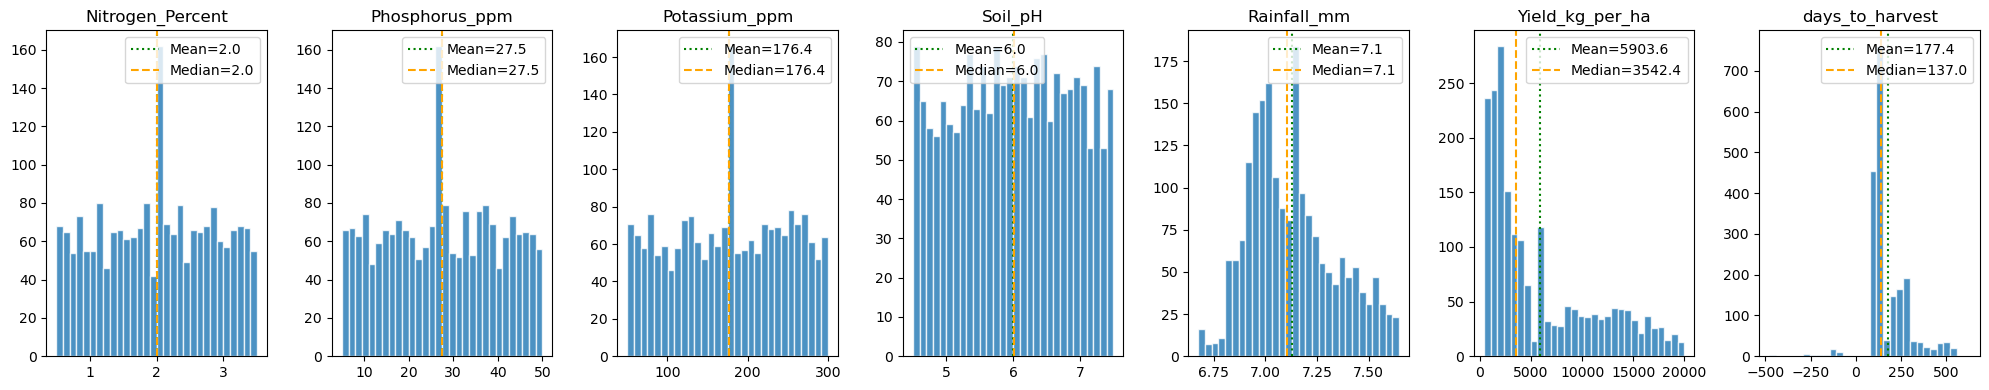

In [201]:
import matplotlib.pyplot as plt

cols = ['Nitrogen_Percent', 'Phosphorus_ppm', 'Potassium_ppm',
        'Soil_pH', 'Rainfall_mm', 'Yield_kg_per_ha', 'days_to_harvest']

fig, axes = plt.subplots(1, len(cols), figsize=(20, 4))

for ax, col in zip(axes, cols):
    data = df[col].dropna()
    
    ax.hist(data, bins=30, alpha=0.8, edgecolor='white')
    
    # Mean line
    ax.axvline(data.mean(), color='green', linestyle=':', label=f"Mean={data.mean():.1f}")
    
    # Median line
    ax.axvline(data.median(), color='orange', linestyle='--', label=f"Median={data.median():.1f}")
    
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

In [202]:
from scipy import stats

cols = ['Nitrogen_Percent', 'Phosphorus_ppm', 'Potassium_ppm',
        'Soil_pH', 'Rainfall_mm', 'Yield_kg_per_ha', 'days_to_harvest']

for col in cols:
    data = df[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    print(f"{col}: Skewness={skew:.3f}, Kurtosis={kurt:.3f}")

# Skewness guide:
# -0.5 to +0.5 : approximately symmetric (OK for most models)
# +0.5 to +1.0 : moderately right-skewed


Nitrogen_Percent: Skewness=-0.029, Kurtosis=-1.100
Phosphorus_ppm: Skewness=-0.019, Kurtosis=-1.112
Potassium_ppm: Skewness=-0.051, Kurtosis=-1.122
Soil_pH: Skewness=-0.023, Kurtosis=-1.137
Rainfall_mm: Skewness=0.500, Kurtosis=-0.443
Yield_kg_per_ha: Skewness=0.970, Kurtosis=-0.336
days_to_harvest: Skewness=0.470, Kurtosis=3.596


In [203]:
# Log transform (for right-skewed, all values > 0)
df['Rainfall_mm'] = np.log1p(df['Rainfall_mm'])   # log1p handles zeros

In [204]:
df['days_to_harvest'].isnull().sum()

np.int64(0)

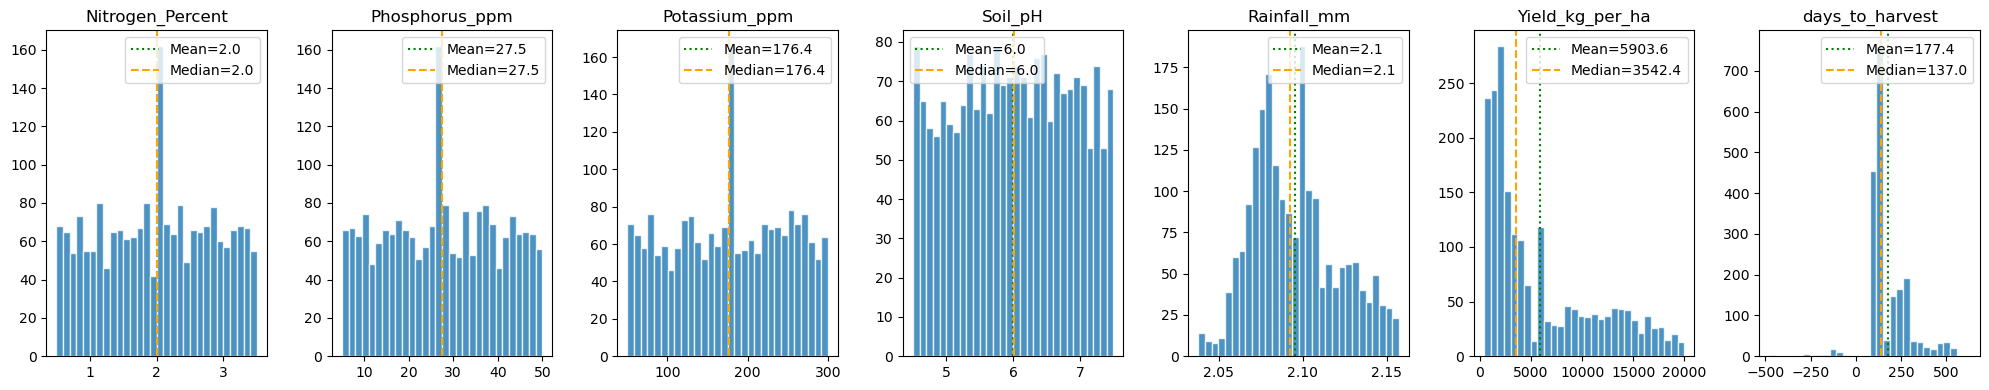

In [205]:
import matplotlib.pyplot as plt

cols = ['Nitrogen_Percent', 'Phosphorus_ppm', 'Potassium_ppm',
        'Soil_pH', 'Rainfall_mm', 'Yield_kg_per_ha', 'days_to_harvest']

fig, axes = plt.subplots(1, len(cols), figsize=(20, 4))

for ax, col in zip(axes, cols):
    data = df[col].dropna()
    
    ax.hist(data, bins=30, alpha=0.8, edgecolor='white')
    
    # Mean line
    ax.axvline(data.mean(), color='green', linestyle=':', label=f"Mean={data.mean():.1f}")
    
    # Median line
    ax.axvline(data.median(), color='orange', linestyle='--', label=f"Median={data.median():.1f}")
    
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

In [206]:
from scipy import stats

cols = ['Nitrogen_Percent', 'Phosphorus_ppm', 'Potassium_ppm',
        'Soil_pH', 'Rainfall_mm', 'Yield_kg_per_ha', 'days_to_harvest']

for col in cols:
    data = df[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    print(f"{col}: Skewness={skew:.3f}, Kurtosis={kurt:.3f}")

# Skewness guide:
# -0.5 to +0.5 : approximately symmetric (OK for most models)
# +0.5 to +1.0 : moderately right-skewed


Nitrogen_Percent: Skewness=-0.029, Kurtosis=-1.100
Phosphorus_ppm: Skewness=-0.019, Kurtosis=-1.112
Potassium_ppm: Skewness=-0.051, Kurtosis=-1.122
Soil_pH: Skewness=-0.023, Kurtosis=-1.137
Rainfall_mm: Skewness=0.450, Kurtosis=-0.483
Yield_kg_per_ha: Skewness=0.970, Kurtosis=-0.336
days_to_harvest: Skewness=0.470, Kurtosis=3.596


C:\Users\Abdul\AppData\Local\Temp\ipykernel_19440\1681110018.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\Abdul\AppData\Local\Temp\ipykernel_19440\1681110018.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\Abdul\AppData\Local\Temp\ipykernel_19440\1681110018.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\Abdul\AppData\Local\Temp\ipykernel_19440\1681110018.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.l

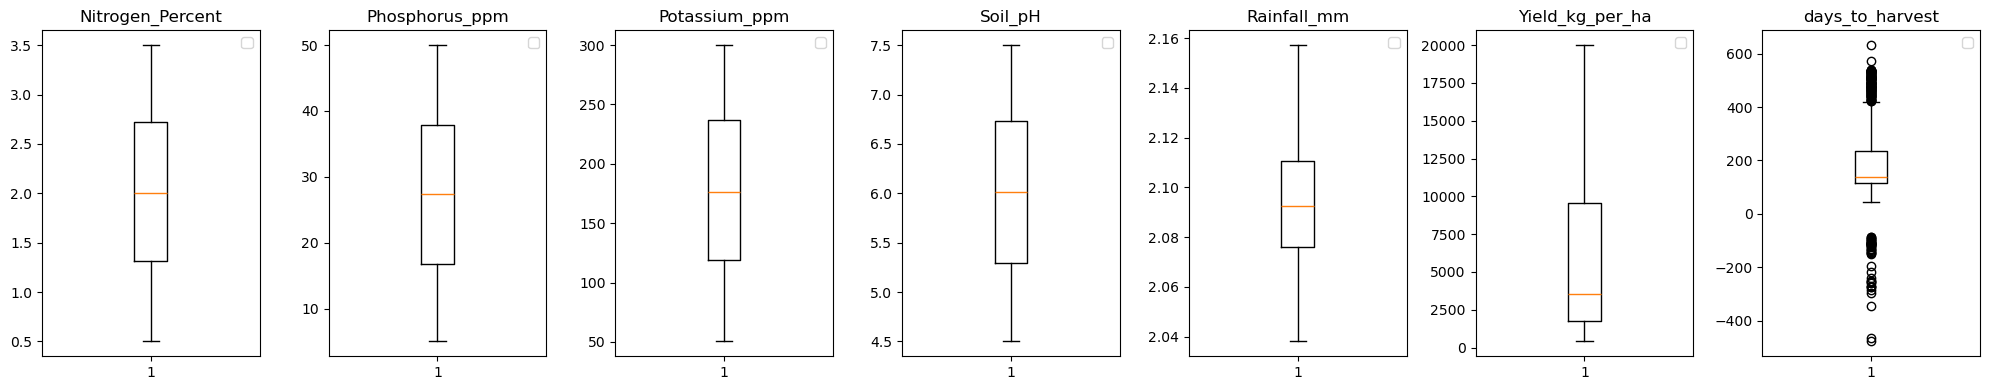

In [207]:
import matplotlib.pyplot as plt

cols = ['Nitrogen_Percent', 'Phosphorus_ppm', 'Potassium_ppm',
        'Soil_pH', 'Rainfall_mm', 'Yield_kg_per_ha', 'days_to_harvest']

fig, axes = plt.subplots(1, len(cols), figsize=(20, 4))

for ax, col in zip(axes, cols):
    data = df[col].dropna()
    
    ax.boxplot(data)
    
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

In [208]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

for col in df.select_dtypes(include=np.number).columns:
    outliers = detect_outliers_iqr(df[col].dropna())
    print(f"{col}: {len(outliers)} outliers detected")


Nitrogen_Percent: 0 outliers detected
Phosphorus_ppm: 0 outliers detected
Potassium_ppm: 0 outliers detected
Soil_pH: 0 outliers detected
Rainfall_mm: 0 outliers detected
Yield_kg_per_ha: 0 outliers detected
days_to_harvest: 149 outliers detected


=== Crop_Type ===
Unique values:   8
Value counts: Crop_Type
Maize        356
Yam          244
Plantain     242
Cassava      239
Soybean      236
Groundnut    233
Rice         232
Cocoa        230
Name: count, dtype: int64
Missing:         0
=== Farm_Location ===
Unique values:   10
Value counts: Farm_Location
Northern         213
Volta            212
Brong Ahafo      209
Central          209
Eastern          202
Upper East       200
Ashanti          198
Greater Accra    197
Western          191
Upper West       181
Name: count, dtype: int64
Missing:         0


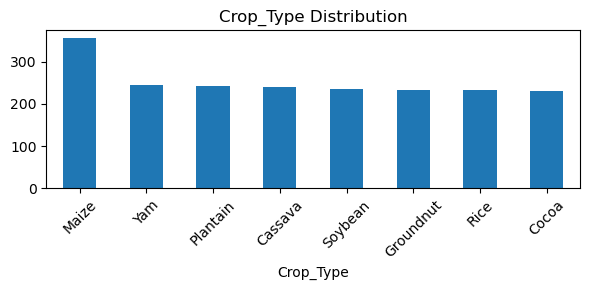

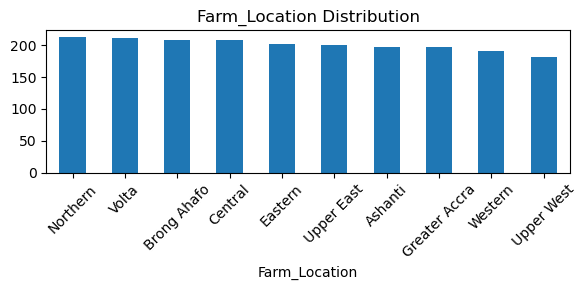

In [209]:
for col in cat_cols:
    print(f"=== {col} ===")
    print(f"Unique values:   {df[col].nunique()}")
    print(f"Value counts: {df[col].value_counts()}")
    print(f"Missing:         {df[col].isnull().sum()}")



for col in cat_cols:
    df[col].value_counts().plot(kind='bar', figsize=(6,3))
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [210]:
region_mapping = {
    # Ashanti
    'Ashanti': 'Ashanti',
    'ASH': 'Ashanti',
    'Ashanti Region': 'Ashanti',

    # Greater Accra
    'Greater Accra': 'Greater Accra',
    'GA': 'Greater Accra',
    'Accra': 'Greater Accra',
    'Greater_Accra': 'Greater Accra',

    # Northern
    'Northern': 'Northern',
    'NR': 'Northern',
    'Northern Region': 'Northern',

    # Others (already clean)
    'Volta': 'Volta',
    'Brong Ahafo': 'Brong Ahafo',
    'Central': 'Central',
    'Eastern': 'Eastern',
    'Upper East': 'Upper East',
    'Upper West': 'Upper West',
    'Western': 'Western'
}


df['Farm_Location'] = df['Farm_Location'].map(region_mapping)

In [211]:
df.shape

(2012, 11)

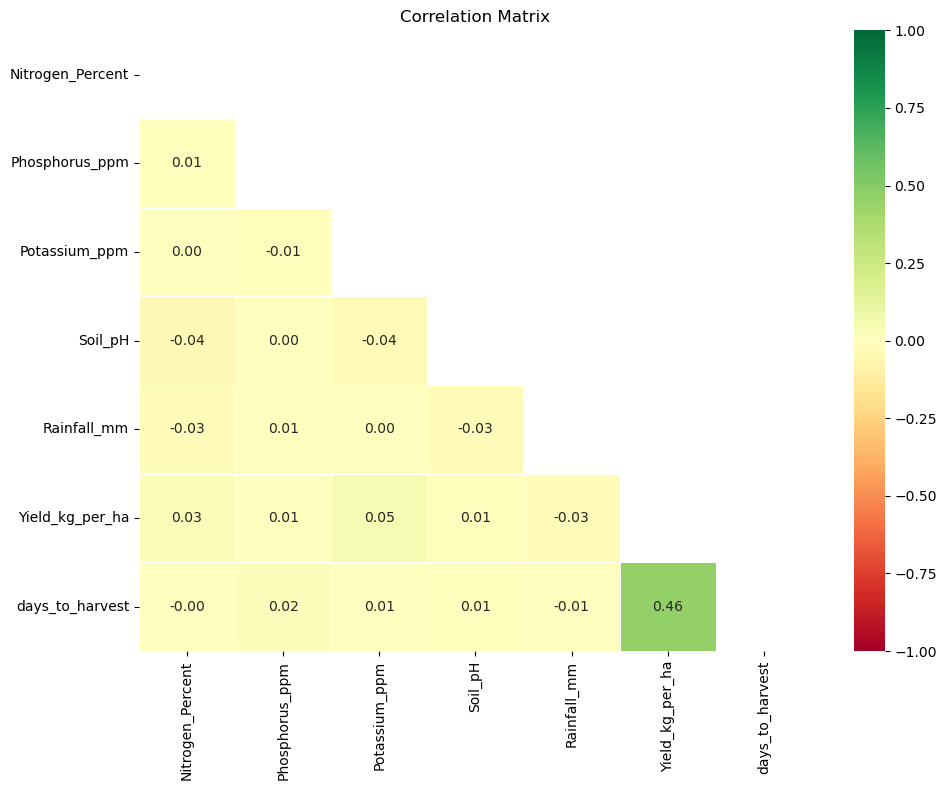

In [212]:
corr = df.select_dtypes(include=np.number).corr()
# Plot lower triangle only (upper is mirror)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", mask=mask,
cmap="RdYlGn", center=0,
linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [230]:
# ONE-HOT ENCODING: for nominal categories (no order), low cardinality (< 15)
df = pd.get_dummies(df, columns= cat_col, dtype = 'int', drop_first=True)

In [231]:
df

,Nitrogen_Percent,Phosphorus_ppm,Potassium_ppm,Soil_pH,Rainfall_mm,Yield_kg_per_ha,Planting_Date,Harvest_Date,days_to_harvest,Crop_Type_Cocoa,...,Crop_Type_Yam,Farm_Location_Brong Ahafo,Farm_Location_Central,Farm_Location_Eastern,Farm_Location_Greater Accra,Farm_Location_Northern,Farm_Location_Upper East,Farm_Location_Upper West,Farm_Location_Volta,Farm_Location_Western
0,0.88,25.900000,210.3,4.58,2.107652,9439.3,2022-05-01,2023-02-28,303,0,...,0,1,0,0,0,0,0,0,0,0
1,1.61,23.800000,278.0,5.87,2.083258,1469.7,2022-08-08,2022-12-15,129,0,...,0,1,0,0,0,0,0,0,0,0
2,2.36,18.900000,243.8,5.66,2.083851,14754.1,2022-10-02,2023-04-04,184,0,...,1,1,0,0,0,0,0,0,0,0
3,1.51,19.100000,187.4,6.66,2.070999,2103.8,2023-08-04,2023-11-22,110,0,...,0,0,0,0,0,0,0,1,0,0
4,2.67,13.500000,146.5,5.72,2.070085,1281.4,2022-04-21,2022-07-29,99,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2055,2.40,27.453037,192.4,5.85,2.068172,600.4,2022-05-19,2023-01-24,250,1,...,0,0,0,0,0,1,0,0,0,0
2056,2.05,5.400000,139.1,6.37,2.097573,12902.8,2023-11-09,2024-03-25,137,0,...,0,1,0,0,0,0,0,0,0,0
2057,1.95,39.400000,114.9,6.62,2.151331,14638.2,2023-04-28,2024-05-02,370,0,...,0,0,0,0,0,0,0,0,0,0
2058,1.39,38.300000,285.9,5.22,2.079893,2256.5,2023-11-04,2024-03-13,130,0,...,0,0,0,0,0,0,1,0,0,0


In [237]:
df

,Nitrogen_Percent,Phosphorus_ppm,Potassium_ppm,Soil_pH,Rainfall_mm,Yield_kg_per_ha,Planting_Date,Harvest_Date,days_to_harvest,Crop_Type_Cocoa,...,Crop_Type_Yam,Farm_Location_Brong Ahafo,Farm_Location_Central,Farm_Location_Eastern,Farm_Location_Greater Accra,Farm_Location_Northern,Farm_Location_Upper East,Farm_Location_Upper West,Farm_Location_Volta,Farm_Location_Western
0,0.88,25.900000,210.3,4.58,2.107652,9439.3,2022-05-01,2023-02-28,303,0,...,0,1,0,0,0,0,0,0,0,0
1,1.61,23.800000,278.0,5.87,2.083258,1469.7,2022-08-08,2022-12-15,129,0,...,0,1,0,0,0,0,0,0,0,0
2,2.36,18.900000,243.8,5.66,2.083851,14754.1,2022-10-02,2023-04-04,184,0,...,1,1,0,0,0,0,0,0,0,0
3,1.51,19.100000,187.4,6.66,2.070999,2103.8,2023-08-04,2023-11-22,110,0,...,0,0,0,0,0,0,0,1,0,0
4,2.67,13.500000,146.5,5.72,2.070085,1281.4,2022-04-21,2022-07-29,99,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2055,2.40,27.453037,192.4,5.85,2.068172,600.4,2022-05-19,2023-01-24,250,1,...,0,0,0,0,0,1,0,0,0,0
2056,2.05,5.400000,139.1,6.37,2.097573,12902.8,2023-11-09,2024-03-25,137,0,...,0,1,0,0,0,0,0,0,0,0
2057,1.95,39.400000,114.9,6.62,2.151331,14638.2,2023-04-28,2024-05-02,370,0,...,0,0,0,0,0,0,0,0,0,0
2058,1.39,38.300000,285.9,5.22,2.079893,2256.5,2023-11-04,2024-03-13,130,0,...,0,0,0,0,0,0,1,0,0,0


In [238]:
#df = df.drop('Farm_ID', axis =1)


# Drop original datetime columns if they are no longer needed
df = df.drop(['Planting_Date', 'Harvest_Date'], axis=1)

In [239]:
X = df.drop('Yield_kg_per_ha', axis=1)
y = df['Yield_kg_per_ha']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [240]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_scaled, y)

# Get coefficients
coef = pd.Series(lasso.coef_, index=X.columns)

# Filter only non-zero features
selected_features = coef[coef != 0].sort_values(ascending=False)

# View vertically in console
for feature, value in selected_features.items():
    print(f"{feature}: {value:.4f}")

days_to_harvest: 398.7513
Potassium_ppm: 106.0250
Farm_Location_Brong Ahafo: 88.4706
Farm_Location_Western: 81.0981
Farm_Location_Central: 73.7314
Farm_Location_Eastern: 69.7752
Phosphorus_ppm: 46.1228
Farm_Location_Upper West: 36.2146
Farm_Location_Upper East: 32.0730
Nitrogen_Percent: 25.5630
Farm_Location_Greater Accra: 21.8507
Soil_pH: 15.3281
Farm_Location_Volta: 14.1172
Farm_Location_Northern: -34.4610
Rainfall_mm: -78.6904
Crop_Type_Yam: -596.0717
Crop_Type_Plantain: -1066.5525
Crop_Type_Rice: -3064.0284
Crop_Type_Soybean: -3557.0200
Crop_Type_Groundnut: -3624.4981
Crop_Type_Maize: -3626.2575
Crop_Type_Cocoa: -4029.8719


C:\Users\Abdul\AppData\Local\Temp\ipykernel_19440\2227498852.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=selected_features.values, y=selected_features.index, palette="viridis")


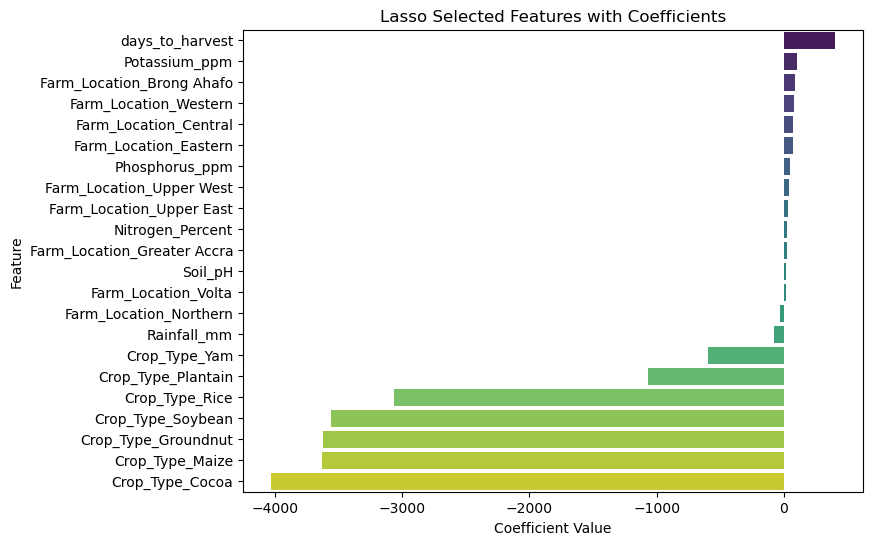

In [241]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(x=selected_features.values, y=selected_features.index, palette="viridis")
plt.title("Lasso Selected Features with Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

In [242]:
selected_features = coef[coef != 0].index.tolist()
print("Selected features:", selected_features)

Selected features: ['Nitrogen_Percent', 'Phosphorus_ppm', 'Potassium_ppm', 'Soil_pH', 'Rainfall_mm', 'days_to_harvest', 'Crop_Type_Cocoa', 'Crop_Type_Groundnut', 'Crop_Type_Maize', 'Crop_Type_Plantain', 'Crop_Type_Rice', 'Crop_Type_Soybean', 'Crop_Type_Yam', 'Farm_Location_Brong Ahafo', 'Farm_Location_Central', 'Farm_Location_Eastern', 'Farm_Location_Greater Accra', 'Farm_Location_Northern', 'Farm_Location_Upper East', 'Farm_Location_Upper West', 'Farm_Location_Volta', 'Farm_Location_Western']


In [243]:
df[selected_features]

,Nitrogen_Percent,Phosphorus_ppm,Potassium_ppm,Soil_pH,Rainfall_mm,days_to_harvest,Crop_Type_Cocoa,Crop_Type_Groundnut,Crop_Type_Maize,Crop_Type_Plantain,...,Crop_Type_Yam,Farm_Location_Brong Ahafo,Farm_Location_Central,Farm_Location_Eastern,Farm_Location_Greater Accra,Farm_Location_Northern,Farm_Location_Upper East,Farm_Location_Upper West,Farm_Location_Volta,Farm_Location_Western
0,0.88,25.900000,210.3,4.58,2.107652,303,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,1.61,23.800000,278.0,5.87,2.083258,129,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
2,2.36,18.900000,243.8,5.66,2.083851,184,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
3,1.51,19.100000,187.4,6.66,2.070999,110,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,2.67,13.500000,146.5,5.72,2.070085,99,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2055,2.40,27.453037,192.4,5.85,2.068172,250,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2056,2.05,5.400000,139.1,6.37,2.097573,137,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
2057,1.95,39.400000,114.9,6.62,2.151331,370,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2058,1.39,38.300000,285.9,5.22,2.079893,130,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
